# Minimal example: from a Kumu Excel to an optimized intervention

This notebook is the runnable companion of the step-by-step tutorial
([HTML version](../docs/tutorial-minimal.html)). It uses the smallest possible model,
[`Minimal.xlsx`](Minimal.xlsx) — one outcome `A`, two levers `B` and `C` — and is the best
template to copy when building your own model.

## Before the spreadsheet: four decisions

1. **Draw the causal loop diagram** (paper, whiteboard, or [Kumu](https://kumu.io)):
   variables, arrows, and a `+`/`-` polarity per arrow. Kumu's Excel export is exactly the
   format SIP reads.
2. **Decide what you want from the model**: the *variables of interest* (VOIs — outcomes you
   want to see vary; here `A`) and the *intervention variables* (levers you could act on;
   here `B` and `C`).
3. **Choose the time unit and the timeframe**: the time unit is the timescale at which you
   want to *see the VOIs vary* (here: years); the timeframe is the horizon of the question
   (here: 10 years).
4. **Classify every variable** with the two-threshold rule:
   - varies more slowly than the *timeframe* → `constant`
   - adjusts to its drivers faster than the *time unit* → `auxiliary`
   - in between (accumulates, has memory) → `stock`

   Here `A` is an auxiliary (responds within a year) and `B`, `C` are constants — note: no
   stocks, so this model has no memory, which we will see in the plots.

## The Excel file

**Elements sheet** — one row per variable:

| Label | Type | Tags | Description | Equation |
|-------|------|------|-------------|----------|
| A | auxiliary | 0 | VOI | `#1*B*C+0.01*#2*B+0.01*#3*C` |
| B | constant | 1 | | |
| C | constant | 1 | | |

- **Type**: the step-4 classification (case-insensitive).
- **Tags**: nonzero marks an intervention; the value is its strength, the sign its direction.
- **Description**: `VOI` marks the variable of interest.
- **Equation** (optional): a custom equation. `#1`, `#2`, ... are parameters sampled from
  `[0, parameter_value_aux]`; `$` marks where an intervention enters; numpy functions are
  available. *Range-scaling trick*: `0.01*#2` is effectively a parameter sampled from a 100×
  smaller range — multiply parameters by constants to give different terms different ranges.
  Here `A` responds mostly to the *product* of `B` and `C`, with weak direct effects.

**Connections sheet** — one row per causal link (`From`, `Type` = polarity, `To`):
`B → A (+)` and `C → A (+)`.

> **Defaults**: with no `Equation`, a variable is a linear combination of its incoming links
> with sampled coefficients — for a stock, that sum is its *rate of change*. With no `$`, an
> intervention shifts a constant's value, a stock's initial condition, and is added to the
> result of an auxiliary's equation.


In [1]:
import numpy as np
from sip_systemsinsightpipeline import Extract, SDM, SDMOptimizer
from sip_systemsinsightpipeline.plots import plot_simulated_intervention_ranking

extract = Extract("Minimal.xlsx")
s = extract.extract_settings()

# Simulation settings
s.seed = 12345                  # Reproducibility
s.N = 50                        # Number of parameter samples
s.t_end = 10                    # Time horizon
s.time_unit = "years"
s.parameter_value_aux = 0.1     # Upper bound for sampled auxiliary/equation parameters
s.parameter_value_stocks = 0.1  # Upper bound for sampled stock parameters

sdm = SDM(s)

Variable of interest: A
with 2 intervention variables
No feedback loops found in the CLD
Custom equation for 'A': #1*B*C+0.01*#2*B+0.01*#3*C
  Variables used: {'B', 'C'}
  Parameters (#): 3
  Intervention ($): No - intervention will be added to result

No interaction terms specified so will solve linear SDM.


## Simulate interventions under parameter uncertainty

Every link coefficient (and every `#` parameter of a custom equation) is unknown, so SIP
samples them `N` times and simulates each tagged intervention for every sample. The ranking
plot shows the distribution of each intervention's effect on the variable of interest at
the final time point.

Running Simulations:   0%|          | 0/50 [00:00<?, ?it/s]

Running Simulations:  32%|███▏      | 16/50 [00:00<00:00, 151.58it/s]

Running Simulations:  64%|██████▍   | 32/50 [00:00<00:00, 153.69it/s]

Running Simulations:  96%|█████████▌| 48/50 [00:00<00:00, 148.93it/s]

Running Simulations: 100%|██████████| 50/50 [00:00<00:00, 148.21it/s]

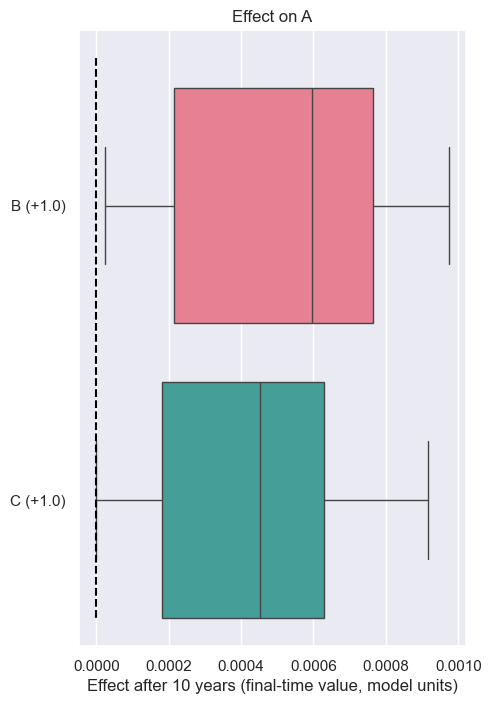

In [2]:
sdm.t_eval = np.linspace(0, s.t_end, 41)  # record 41 time points for smooth trajectory plots
df_sol_per_sample, param_samples = sdm.run_simulations()
intervention_effects = sdm.get_intervention_effects()

voi = s.variable_of_interest[0]
fig = plot_simulated_intervention_ranking(s, intervention_effects[voi], voi)

### Behavior over time: trajectories

`plot_trajectories` shows how any variable evolves across the uncertainty ensemble —
median with a percentile band, or `kind='spaghetti'` for individual parameter draws.
Here the curves are **flat**: this model has no stocks, so nothing accumulates — exactly
what the classification predicted. Once a model has stocks and feedback loops, these curves
take one of a handful of classic shapes (exponential growth, goal-seeking, S-shaped growth,
overshoot & collapse, oscillation); see
[Reading trajectories: the classic shapes](../docs/trajectories-and-archetypes.html).

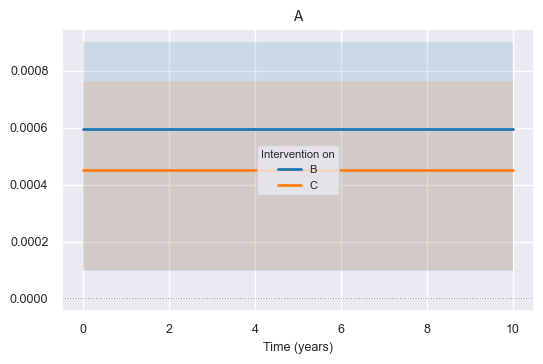

In [3]:
from sip_systemsinsightpipeline.plots import plot_trajectories

fig = plot_trajectories(sdm, interventions='all')   # one colour per intervention run

## Optimize a budget split between interventions

Instead of testing one intervention at a time, the optimizer allocates a **budget** across
all interventions. It works in expenditure space: each intervention gets an expenditure
`y_i = cost_i * intensity_i`, subject to `y_i >= 0` and `sum(y) <= budget`. Multi-start
SLSQP (Sobol-seeded) finds the allocation that maximizes (or minimizes) the variable of
interest, and reports near-optimal alternatives ("equilibria") when several allocations
perform comparably.

In [4]:
params = sdm.sample_model_parameters()  # one parameter draw
costs = [1.0] * len(s.intervention_variables)

optimizer = SDMOptimizer(sdm)
result = optimizer.optimize_intervention_intensities(
    params=params,
    costs=costs,
    variable_of_interest=voi,
    budget=1.0,
    maximize=True,
    n_starts=8,
    seed=1,
)

print("Success:", result["success"])
print("Best effect size:", round(result["best_effect_size"], 5))
print("Near-optimal allocations found:", result["n_equilibria"])
for var, intensity in zip(s.intervention_variables, result["best_intensities"]):
    print(f"  {var}: intensity {intensity:.3f}")

Success: True
Best effect size: 0.0235
Near-optimal allocations found: 2
  B: intensity 0.503
  C: intensity 0.497


Because `A`'s equation rewards the *product* `B*C`, the optimal allocation splits the
budget roughly evenly between the two interventions instead of spending it all on one —
something a one-intervention-at-a-time ranking cannot reveal.

## How robust is the optimal allocation?

Re-running the optimization for many parameter draws shows how the optimal allocation
shifts with parameter uncertainty. The result is a tidy DataFrame with one row per
near-optimal allocation per parameter sample.

In [5]:
opt_df = optimizer.optimize_across_parameter_samples(
    costs=costs,
    variable_of_interest=voi,
    maximize=True,
    n_starts=4,
    seed=1,
)

intensity_cols = [c for c in opt_df.columns if c.startswith("intensity_")]
print(f"{len(opt_df)} allocations across {opt_df['sample_idx'].nunique()} parameter samples")
print("\nMean optimal intensity per intervention:")
print(opt_df[intensity_cols].mean().round(3).to_string())
opt_df.head()

Optimizing across parameter samples (multistart_slsqp):   0%|          | 0/50 [00:00<?, ?it/s]

Optimizing across parameter samples (multistart_slsqp):   2%|▏         | 1/50 [00:00<00:21,  2.32it/s]

Optimizing across parameter samples (multistart_slsqp):   4%|▍         | 2/50 [00:00<00:15,  3.01it/s]

Optimizing across parameter samples (multistart_slsqp):   6%|▌         | 3/50 [00:01<00:18,  2.61it/s]

Optimizing across parameter samples (multistart_slsqp):   8%|▊         | 4/50 [00:01<00:21,  2.18it/s]

...

Optimizing across parameter samples (multistart_slsqp):  98%|█████████▊| 49/50 [00:18<00:00,  3.56it/s]

Optimizing across parameter samples (multistart_slsqp): 100%|██████████| 50/50 [00:18<00:00,  3.24it/s]

Optimizing across parameter samples (multistart_slsqp): 100%|██████████| 50/50 [00:18<00:00,  2.69it/s]

137 allocations across 50 parameter samples

Mean optimal intensity per intervention:
intensity_B    0.502
intensity_C    0.498


,sample_idx,equilibrium_idx,voi_effect_size,total_cost,n_equilibria,success,param_A__Intercept,param_A____eq_params_A____#1,param_A____eq_params_A____#2,param_A____eq_params_A____#3,param_A__B,param_A__C,intensity_B,intensity_C
0,0,0,0.010590,0.999984,4,True,0,0.041361,0.042494,0.007438,0.025511,0.04950,0.504230,0.495754
1,0,1,0.010590,0.999964,4,True,0,0.041361,0.042494,0.007438,0.025511,0.04950,0.504220,0.495744
2,0,2,0.010585,0.999735,4,True,0,0.041361,0.042494,0.007438,0.025511,0.04950,0.504106,0.495630
3,0,3,0.010585,0.999718,4,True,0,0.041361,0.042494,0.007438,0.025511,0.04950,0.504097,0.495621
4,1,0,0.020529,0.999999,2,True,0,0.079758,0.038150,0.079716,0.060339,0.07472,0.497394,0.502605


## Next steps

- [`Insulation.ipynb`](Insulation.ipynb) applies the same workflow to a real-world model of
  household energy decisions, including sensitivity analysis and feedback-loop dominance
  (Loops That Matter).
- The [README](../README.md) documents the Excel format and the API in more detail.